In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Iris (1).csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (150, 6)
   ID  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [3]:
# remove ID column
if "Id" in df.columns:
    df = df.drop("Id", axis=1)

print(df.columns)

Index(['ID', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


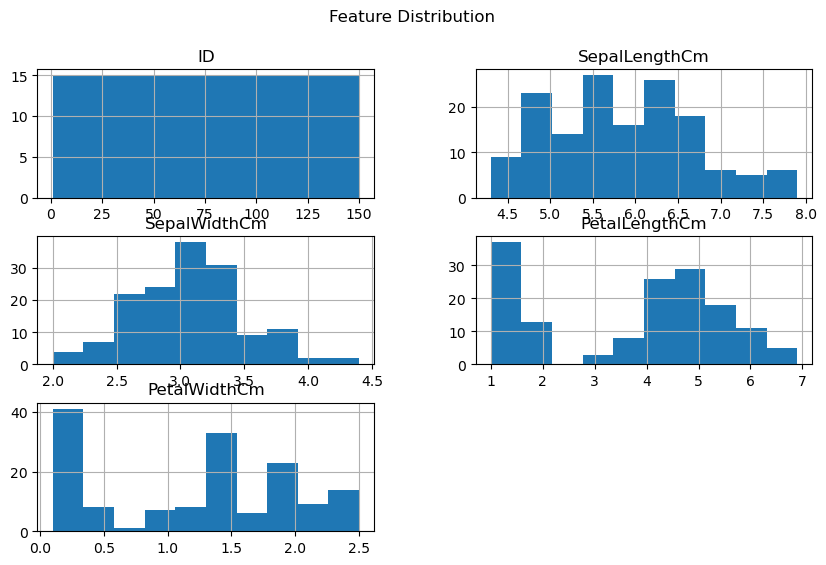

In [4]:
df.hist(figsize=(10,6))
plt.suptitle("Feature Distribution")
plt.show()

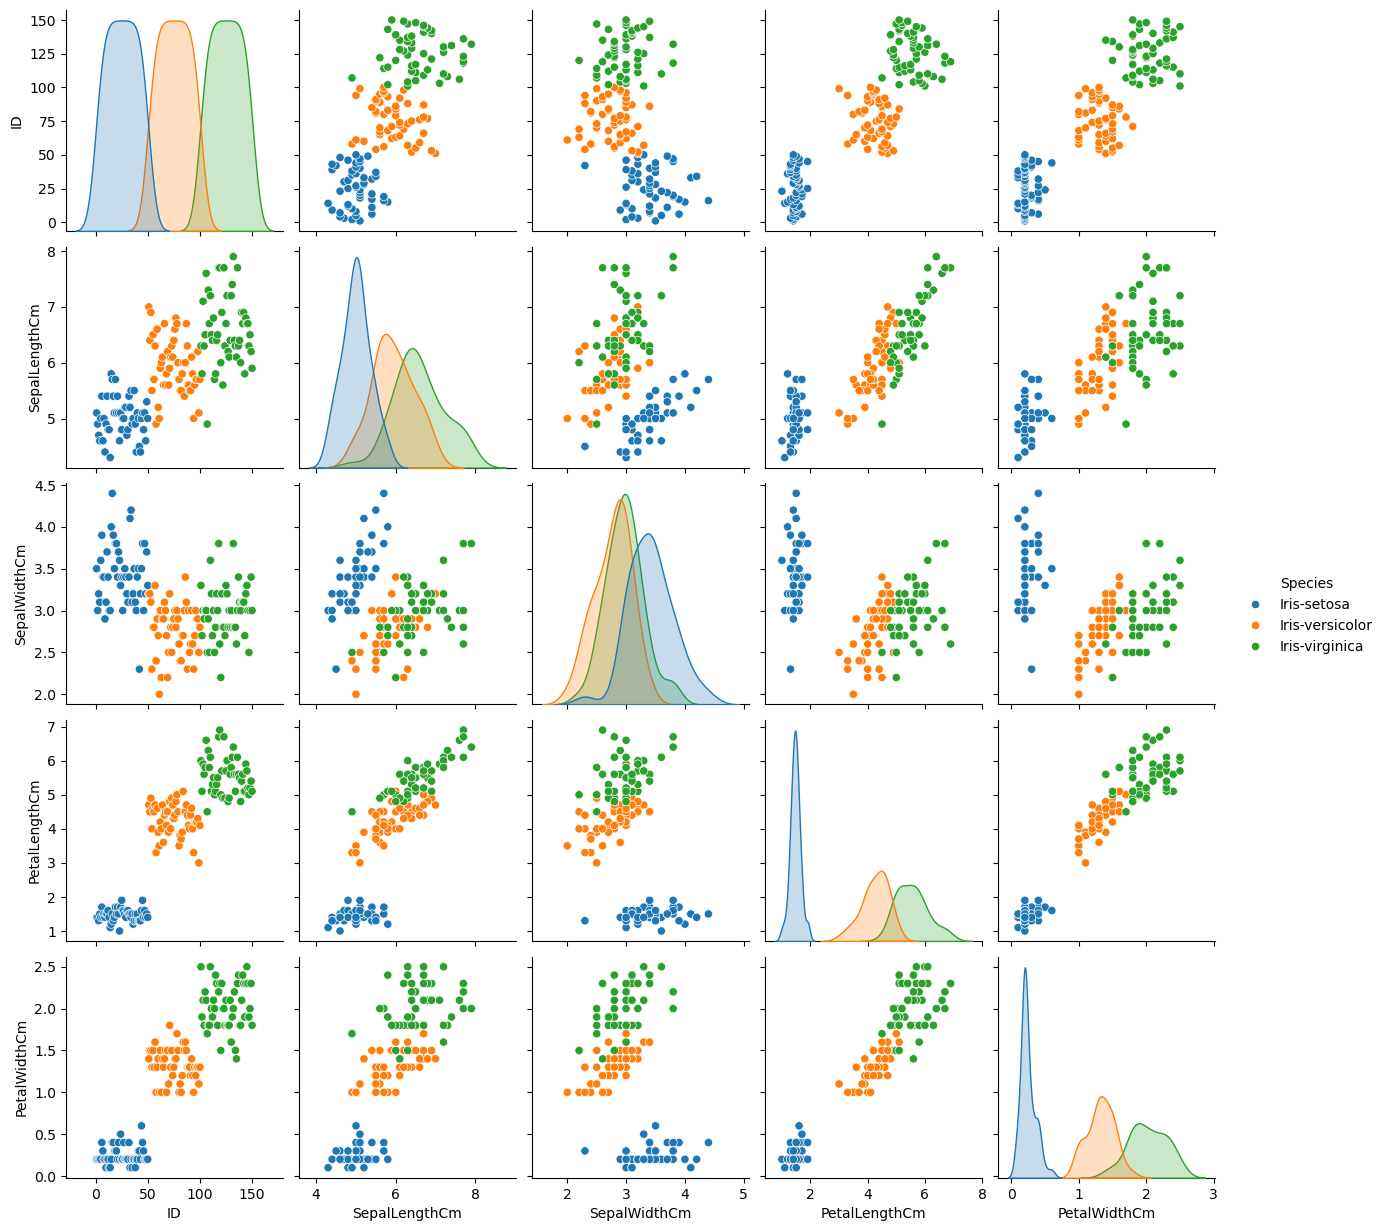

In [5]:
sns.pairplot(df, hue="Species")
plt.show()

In [6]:
X = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y = df['Species']

print("Feature count:", X.shape[1])

Feature count: 4


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    acc = accuracy_score(y_test, predictions)
    
    results[name] = acc
    
    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 1.0
SVM Accuracy: 1.0
Random Forest Accuracy: 1.0


In [10]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    acc = accuracy_score(y_test, predictions)
    
    results[name] = acc
    
    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 1.0
SVM Accuracy: 1.0
Random Forest Accuracy: 1.0


In [11]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [12]:
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [14]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



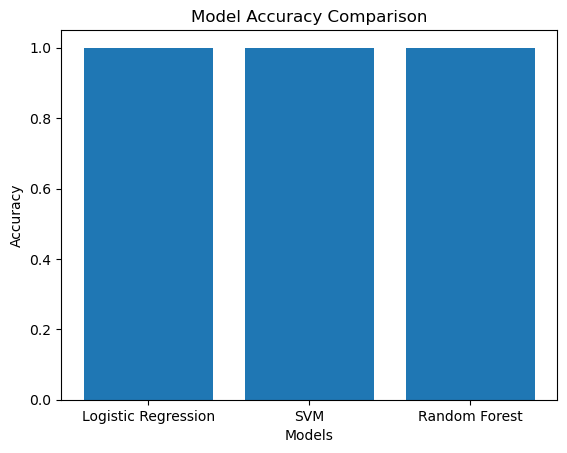

In [15]:
plt.bar(results.keys(), results.values())

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [16]:
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [None,5,10],
    'min_samples_split': [2,4]
}

grid = GridSearchCV(RandomForestClassifier(),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 4, 'n_estimators': 50}


In [17]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



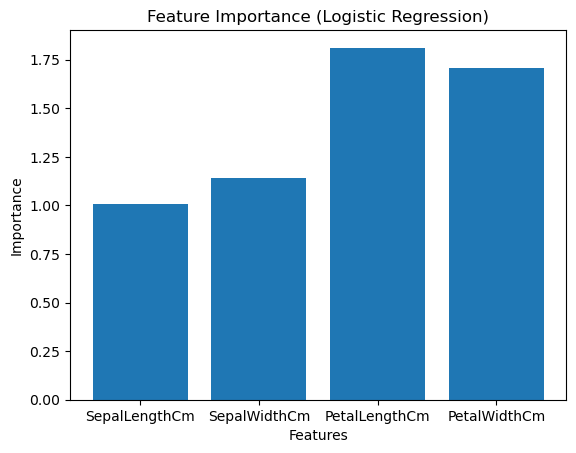

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression feature importance
importances = np.abs(best_model.coef_[0])

features = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']

plt.bar(features, importances)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [19]:
sample = [[5.1, 3.5, 1.4, 0.2]]

sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)

print("Predicted Flower:", prediction)

Predicted Flower: ['Iris-setosa']


c:\Users\shristi verma\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
import pickle

In [ ]:
import pickle
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names) 
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

with open("irisflower.pkl", "wb") as file:
    pickle.dump(model, file)